<a href="https://colab.research.google.com/github/Guilher-cell/Cp2_MLAM_2Sem/blob/main/Regressao_Linear_Energia_Solar_Basica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão Linear com Dados de Energia Solar (PVGIS)

**Grupo / Aluno(s):** Renato sandreschi, Andre shiguematsu, Guilherme belo, Conrado gracie


**Objetivo:** utilizar dados horários do PVGIS para treinar dois modelos de Regressão Linear, estimar a potência fotovoltaica e comparar os resultados usando MAE, MSE e R².

## Importação das bibliotecas

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Consulta dos dados no PVGIS

Neste trabalho vamos utilizar dados de energia solar da cidade de Campinas - SP.

In [ ]:
# Dados da localização
cidade = "Campinas - SP"
latitude = -22.9056
longitude = -47.0608
ano_inicio = 2019
ano_fim = 2020

# Parâmetros da consulta
params = {
    "lat": latitude,
    "lon": longitude,
    "startyear": ano_inicio,
    "endyear": ano_fim,
    "pvcalculation": 1,
    "peakpower": 1,
    "loss": 14,
    "optimalangles": 1,
    "outputformat": "json"
}

url = "https://re.jrc.ec.europa.eu/api/v5_3/seriescalc"
resposta = requests.get(url, params=params)

print("Cidade:", cidade)
print("Período:", ano_inicio, "a", ano_fim)
print("Status da consulta:", resposta.status_code)

Cidade: Campinas - SP
Período: 2019 a 2020
Status da consulta: 200


In [ ]:
# Transformando a resposta da API em dados
dados = resposta.json()

print("Chaves principais:", list(dados.keys()))
print("\nExemplo de registro:")
print(dados["outputs"]["hourly"][0])

Chaves principais: ['inputs', 'outputs', 'meta']

Exemplo de registro:
{'time': '20190101:0003', 'P': 0.0, 'G(i)': 0.0, 'H_sun': 0.0, 'T2m': 23.71, 'WS10m': 4.76, 'Int': 0.0}


### Organização dos dados

Vamos transformar os dados recebidos em um DataFrame e manter somente as colunas utilizadas no trabalho.

In [ ]:
dataset = pd.DataFrame(dados["outputs"]["hourly"])

# Transformando a coluna de tempo
dataset["time"] = pd.to_datetime(dataset["time"], format="%Y%m%d:%H%M")

# Selecionando as colunas necessárias
dataset = dataset[["time", "P", "G(i)", "T2m", "WS10m", "H_sun"]]

display(dataset.head())

,time,P,G(i),T2m,WS10m,H_sun
0,2019-01-01 00:03:00,0.0,0.0,23.71,4.76,0.0
1,2019-01-01 01:03:00,0.0,0.0,22.82,4.14,0.0
2,2019-01-01 02:03:00,0.0,0.0,22.11,3.79,0.0
3,2019-01-01 03:03:00,0.0,0.0,21.66,3.38,0.0
4,2019-01-01 04:03:00,0.0,0.0,21.27,2.83,0.0


### 1. Análise inicial dos dados

In [ ]:
print("Linhas:", dataset.shape[0])
print("Colunas:", dataset.shape[1])
print("\nColunas do dataset:")
print(dataset.columns)

print("\nInformações dos dados:")
dataset.info()

print("\nValores ausentes:")
print(dataset.isnull().sum())

Linhas: 17544
Colunas: 6

Colunas do dataset:
Index(['time', 'P', 'G(i)', 'T2m', 'WS10m', 'H_sun'], dtype='object')

Informações dos dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    17544 non-null  datetime64[ns]
 1   P       17544 non-null  float64       
 2   G(i)    17544 non-null  float64       
 3   T2m     17544 non-null  float64       
 4   WS10m   17544 non-null  float64       
 5   H_sun   17544 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 822.5 KB

Valores ausentes:
time     0
P        0
G(i)     0
T2m      0
WS10m    0
H_sun    0
dtype: int64


In [ ]:
dataset.describe()

,time,P,G(i),T2m,WS10m,H_sun
count,17544,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000
mean,2020-01-01 11:32:59.999999488,178.763374,236.796125,21.324037,2.574692,18.782432
min,2019-01-01 00:03:00,0.000000,0.000000,5.420000,0.000000,0.000000
25%,2019-07-02 17:48:00,0.000000,0.000000,17.900000,1.660000,0.000000
50%,2020-01-01 11:33:00,0.000000,0.000000,21.130000,2.340000,0.000000
75%,2020-07-02 05:18:00,361.802500,467.602500,24.810000,3.450000,36.970000
max,2020-12-31 23:03:00,841.190000,1113.630000,38.070000,7.380000,89.700000
std,NaN,255.811315,336.580656,5.079783,1.242006,24.442902


## 2.Remoção dos registros sem geração

Os registros em que `G(i) = 0` representam períodos sem irradiância. Como o objetivo é estimar a potência durante a geração solar, vamos utilizar apenas registros com `G(i) > 0`.

In [ ]:
dataset = dataset[dataset["G(i)"] > 0].copy()

print("Quantidade de registros após o filtro:", dataset.shape[0])
display(dataset.head())

Quantidade de registros após o filtro: 8627


,time,P,G(i),T2m,WS10m,H_sun
9,2019-01-01 09:03:00,72.02,115.15,20.23,1.38,7.01
10,2019-01-01 10:03:00,320.34,418.55,23.37,1.52,20.02
11,2019-01-01 11:03:00,513.34,663.95,25.34,2.41,33.35
12,2019-01-01 12:03:00,638.66,837.74,26.61,2.97,46.89
13,2019-01-01 13:03:00,453.06,593.92,27.61,2.90,60.56


## 4.Definição das variáveis

A variável que queremos estimar é a potência fotovoltaica `P`.

Vamos utilizar como variáveis de entrada `G(i)`, `H_sun`, `T2m` e `WS10m`.

In [ ]:
X = dataset[["G(i)", "H_sun", "T2m", "WS10m"]]
y = dataset["P"]

print("Variáveis de entrada:")
print(X.columns)
print("\nVariável alvo:", y.name)

Variáveis de entrada:
Index(['G(i)', 'H_sun', 'T2m', 'WS10m'], dtype='object')

Variável alvo: P


## 5. Visualização dos dados

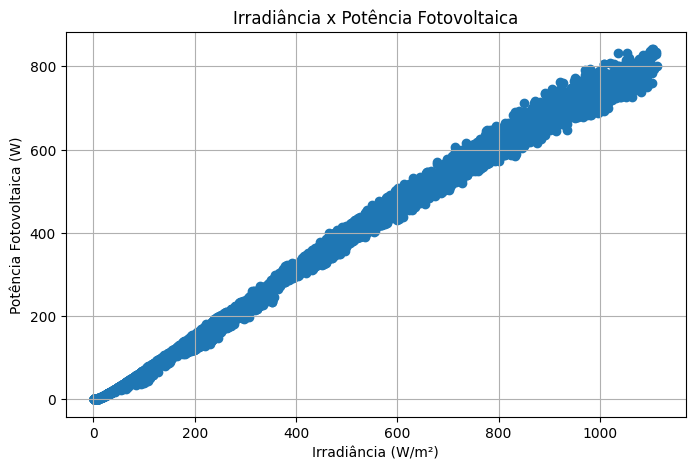

In [ ]:
# Irradiância x Potência

plt.figure(figsize=(8, 5))

plt.scatter(dataset["G(i)"], dataset["P"])

plt.xlabel("Irradiância (W/m²)")
plt.ylabel("Potência Fotovoltaica (W)")
plt.title("Irradiância x Potência Fotovoltaica")

plt.grid()
plt.show()

In [ ]:
print("Correlação das variáveis com a potência:")
print(dataset[["P", "G(i)", "H_sun", "T2m", "WS10m"]].corr()["P"].sort_values(ascending=False))

Correlação das variáveis com a potência:
P        1.000000
G(i)     0.997766
H_sun    0.693693
T2m      0.220223
WS10m    0.035307
Name: P, dtype: float64


## 6. Matriz de correlação

,P,G(i),H_sun,T2m,WS10m
P,1.000000,0.997766,0.693693,0.220223,0.035307
G(i),0.997766,1.000000,0.708962,0.258621,0.010773
H_sun,0.693693,0.708962,1.000000,0.468354,0.075536
T2m,0.220223,0.258621,0.468354,1.000000,-0.110191
WS10m,0.035307,0.010773,0.075536,-0.110191,1.000000


Correlação com a potência:
P        1.000000
G(i)     0.997766
H_sun    0.693693
T2m      0.220223
WS10m    0.035307
Name: P, dtype: float64


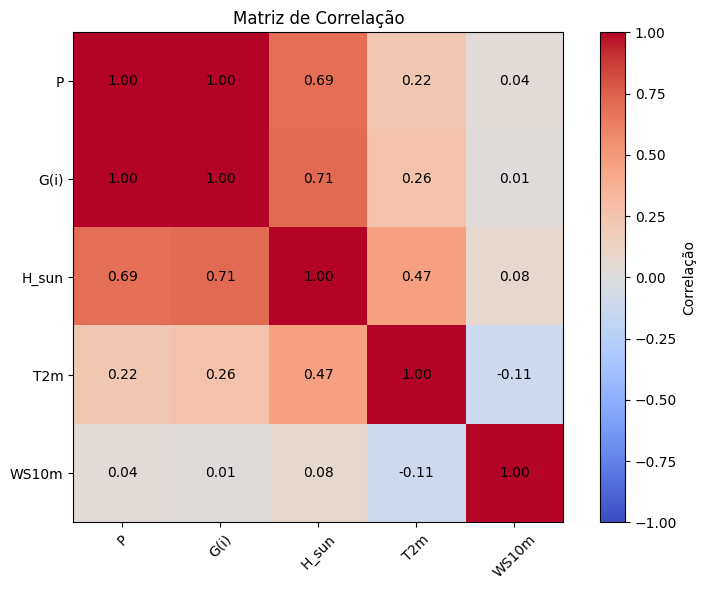

In [ ]:
correlacao = dataset[["P", "G(i)", "H_sun", "T2m", "WS10m"]].corr()

display(correlacao)

print("Correlação com a potência:")

print(correlacao["P"].sort_values(ascending=False))

## 6. Matriz de correlação

correlacao = dataset[["P", "G(i)", "H_sun", "T2m", "WS10m"]].corr()

plt.figure(figsize=(8, 6))

plt.imshow(correlacao, cmap="coolwarm", vmin=-1, vmax=1)

plt.xticks(range(len(correlacao.columns)), correlacao.columns, rotation=45)
plt.yticks(range(len(correlacao.columns)), correlacao.columns)

plt.colorbar(label="Correlação")

# Coloca os valores dentro das células
for i in range(len(correlacao.columns)):
    for j in range(len(correlacao.columns)):
        plt.text(
            j,
            i,
            f"{correlacao.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()

## 8. Separação dos dados para treinamento e teste

Vamos utilizar 80% dos dados para treinamento e 20% para teste. O `random_state=42` permite repetir a mesma divisão dos dados.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (6901, 4)
X_test: (1726, 4)
y_train: (6901,)
y_test: (1726,)


## 9. Modelo 1 — todas as variáveis

Neste modelo vamos utilizar as quatro variáveis: `G(i)`, `H_sun`, `T2m` e `WS10m`.

In [ ]:
modelo1 = LinearRegression()
modelo1.fit(X_train, y_train)

y_pred1 = modelo1.predict(X_test)

mae1 = mean_absolute_error(y_test, y_pred1)
mse1 = mean_squared_error(y_test, y_pred1)
r2_1 = r2_score(y_test, y_pred1)

print("Modelo 1")
print("MAE:", mae1)
print("MSE:", mse1)
print("R²:", r2_1)

Modelo 1
MAE: 9.866026745205328
MSE: 152.0427437027619
R²: 0.9976541896675637


## 10. Modelo 2 — duas variáveis

No segundo modelo vamos utilizar somente `G(i)` e `T2m`. Assim podemos comparar se as outras variáveis acrescentam informação ao modelo.

In [ ]:
X2 = dataset[["G(i)", "T2m"]]
y2 = dataset["P"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42
)

modelo2 = LinearRegression()
modelo2.fit(X_train2, y_train2)

y_pred2 = modelo2.predict(X_test2)

mae2 = mean_absolute_error(y_test2, y_pred2)
mse2 = mean_squared_error(y_test2, y_pred2)
r2_2 = r2_score(y_test2, y_pred2)

print("Modelo 2")
print("MAE:", mae2)
print("MSE:", mse2)
print("R²:", r2_2)

Modelo 2
MAE: 10.391926671946205
MSE: 177.8959052438334
R²: 0.9972553109575889


## 11. Comparação dos modelos

In [ ]:
resultado = pd.DataFrame({
    "Modelo": ["Modelo 1", "Modelo 2"],
    "MAE": [mae1, mae2],
    "MSE": [mse1, mse2],
    "R²": [r2_1, r2_2]
})

display(resultado)

,Modelo,MAE,MSE,R²
0,Modelo 1,9.866027,152.042744,0.997654
1,Modelo 2,10.391927,177.895905,0.997255


In [ ]:
if r2_1 > r2_2:
    print("O Modelo 1 apresentou o maior R².")
else:
    print("O Modelo 2 apresentou o maior R².")

if mae1 < mae2:
    print("O Modelo 1 apresentou o menor MAE.")
else:
    print("O Modelo 2 apresentou o menor MAE.")

if mse1 < mse2:
    print("O Modelo 1 apresentou o menor MSE.")
else:
    print("O Modelo 2 apresentou o menor MSE.")

O Modelo 1 apresentou o maior R².
O Modelo 1 apresentou o menor MAE.
O Modelo 1 apresentou o menor MSE.


## 12. Conclusão

Os dois modelos foram treinados utilizando Regressão Linear e avaliados com MAE, MSE e R². O modelo escolhido deve considerar o conjunto das métricas, principalmente o maior R² e os menores valores de MAE e MSE.

A irradiância `G(i)` apresenta uma relação importante com a potência fotovoltaica, pois representa a quantidade de energia solar disponível para a geração. As outras variáveis podem contribuir para explicar parte das diferenças na potência produzida.

O modelo de Regressão Linear apresenta uma forma simples de estimar a potência, mas os resultados podem ser afetados por fatores como clima, temperatura, nebulosidade e outras condições que não estão representadas no modelo.